In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

analysis_dir = "/content/drive/MyDrive/CAT2000/analysis"

pretrained = np.load(
    os.path.join(analysis_dir, "pretrained_analysis.npy"),
    allow_pickle=True
).item()

scratch = np.load(
    os.path.join(analysis_dir, "scratch_analysis.npy"),
    allow_pickle=True
).item()

print("Loaded successfully.\n")

print("Metrics found:")
print(pretrained.keys())

Loaded successfully.

Metrics found:
dict_keys(['entropy', 'spatial_corr', 'smoothness'])


In [23]:
metrics = ["entropy", "spatial_corr", "smoothness"]

rows = []

for metric in metrics:

    pre = pretrained[metric]
    scr = scratch[metric]

    rows.append({
        "Metric": metric,
        "Pretrained Mean": np.mean(pre),
        "Pretrained Std": np.std(pre),
        "Scratch Mean": np.mean(scr),
        "Scratch Std": np.std(scr)
    })

summary = pd.DataFrame(rows)

display(summary)

summary.to_csv(
    "/content/drive/MyDrive/CAT2000/analysis/results_summary.csv",
    index=False
)

print("\nSummary table saved.")

,Metric,Pretrained Mean,Pretrained Std,Scratch Mean,Scratch Std
0,entropy,8.545672,0.636382,10.946608,0.074024
1,spatial_corr,0.000721,0.001959,0.183868,0.013185
2,smoothness,0.025043,0.027461,0.087128,0.014483



Summary table saved.


In [24]:
import pandas as pd
from scipy.stats import ttest_ind

metrics = ["entropy", "spatial_corr", "smoothness"]

rows = []

for metric in metrics:

    pre = pretrained[metric]
    scr = scratch[metric]

    t_stat, p_value = ttest_ind(
        pre,
        scr,
        equal_var=False
    )

    pooled_std = np.sqrt(
        (
            ((len(pre)-1) * np.var(pre, ddof=1)) +
            ((len(scr)-1) * np.var(scr, ddof=1))
        ) /
        (len(pre) + len(scr) - 2)
    )

    cohen_d = (
        np.mean(scr) - np.mean(pre)
    ) / pooled_std

    rows.append({
        "Metric": metric,
        "t-statistic": t_stat,
        "p-value": p_value,
        "Cohen_d": cohen_d
    })

stats_df = pd.DataFrame(rows)

display(stats_df)

stats_df.to_csv(
    "/content/drive/MyDrive/CAT2000/analysis/statistical_tests.csv",
    index=False
)

print("Statistical analysis saved.")

,Metric,t-statistic,p-value,Cohen_d
0,entropy,-57.707182,3.260504e-146,4.782896
1,spatial_corr,-168.958962,6.857864e-177,21.913996
2,smoothness,-29.093859,1.252581e-98,2.655303


Statistical analysis saved.


/tmp/ipykernel_1952/2405201715.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_1952/2405201715.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_1952/2405201715.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


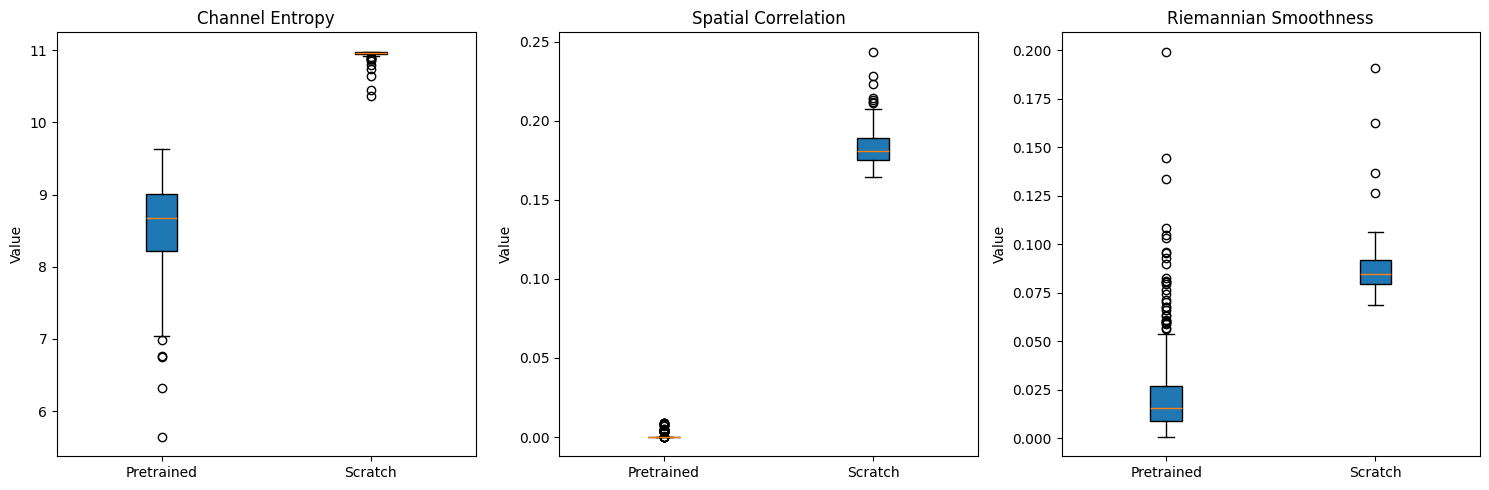

In [25]:
import matplotlib.pyplot as plt

metrics = [
    ("entropy", "Channel Entropy"),
    ("spatial_corr", "Spatial Correlation"),
    ("smoothness", "Riemannian Smoothness")
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (metric, title) in zip(axes, metrics):

    ax.boxplot(
        [
            pretrained[metric],
            scratch[metric]
        ],
        labels=["Pretrained", "Scratch"],
        patch_artist=True
    )

    ax.set_title(title)
    ax.set_ylabel("Value")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/CAT2000/analysis/Figure1_Boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

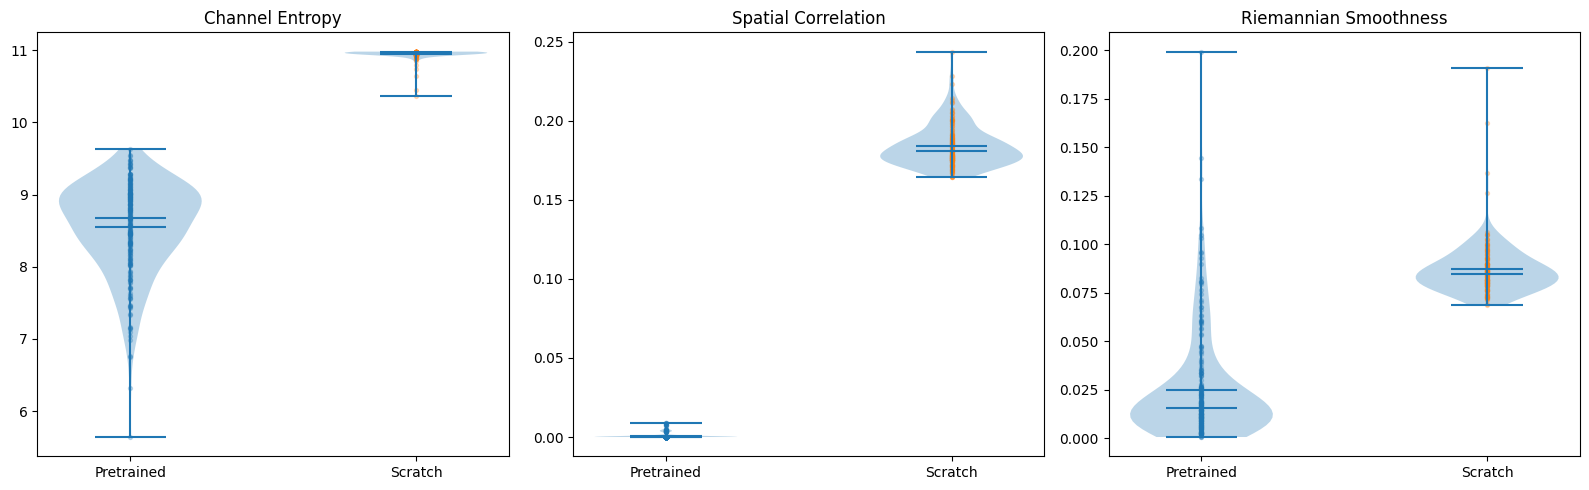

In [26]:
import matplotlib.pyplot as plt

metrics = [
    ("entropy", "Channel Entropy"),
    ("spatial_corr", "Spatial Correlation"),
    ("smoothness", "Riemannian Smoothness")
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metric, title) in zip(axes, metrics):

    data = [
        pretrained[metric],
        scratch[metric]
    ]

    violin = ax.violinplot(
        data,
        showmeans=True,
        showmedians=True
    )

    ax.scatter(
        np.ones(len(pretrained[metric])),
        pretrained[metric],
        alpha=0.25,
        s=8
    )

    ax.scatter(
        np.ones(len(scratch[metric])) * 2,
        scratch[metric],
        alpha=0.25,
        s=8
    )

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Pretrained", "Scratch"])
    ax.set_title(title)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/CAT2000/analysis/Figure2_ViolinPlots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
import torch

pretrained_inf = torch.load(
    "/content/drive/MyDrive/CAT2000/pretrained_inference.pt",
    map_location="cpu"
)

scratch_inf = torch.load(
    "/content/drive/MyDrive/CAT2000/scratch_inference.pt",
    map_location="cpu"
)

print("Pretrained:", pretrained_inf.keys())
print("Scratch   :", scratch_inf.keys())

print(pretrained_inf["images"].shape)
print(scratch_inf["images"].shape)

Pretrained: dict_keys(['images', 'features', 'predictions', 'ground_truth', 'categories'])
Scratch   : dict_keys(['images', 'features', 'predictions', 'ground_truth', 'categories'])
torch.Size([240, 3, 224, 224])
torch.Size([240, 3, 224, 224])


In [3]:
images = pretrained_inf["images"]

print(images.shape)

torch.Size([240, 3, 224, 224])


IndexError: index 163 is out of bounds for dimension 0 with size 151

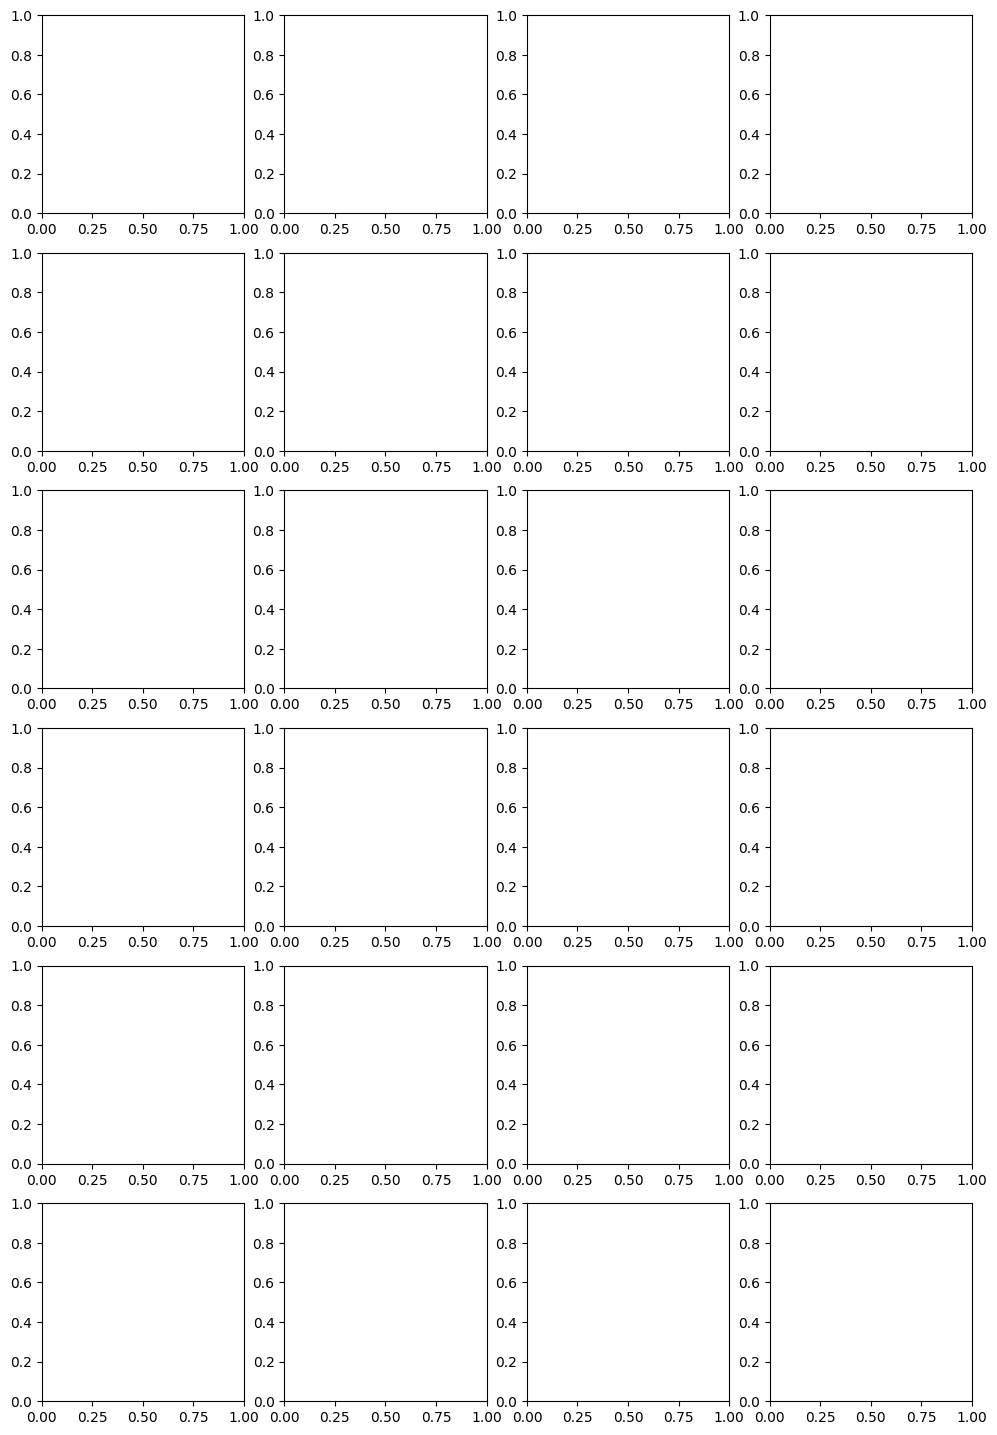

In [4]:
import random
import matplotlib.pyplot as plt
import numpy as np

random.seed(42)

indices = random.sample(range(len(images)), 6)

fig, axes = plt.subplots(len(indices), 4, figsize=(12, 18))

for row, idx in enumerate(indices):

    # Recover RGB image
    rgb = images[idx].permute(1, 2, 0).numpy()
    rgb = rgb * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    rgb = np.clip(rgb, 0, 1)

    gt = pretrained_inf["ground_truth"][idx, 0].numpy()
    scratch = scratch_inf["predictions"][idx, 0].numpy()
    pretrained_pred = pretrained_inf["predictions"][idx, 0].numpy()

    titles = ["Image", "Ground Truth", "Scratch", "Pretrained"]
    imgs = [rgb, gt, scratch, pretrained_pred]

    for col in range(4):
        if col == 0:
            axes[row, col].imshow(imgs[col])
        else:
            axes[row, col].imshow(imgs[col], cmap="hot")

        axes[row, col].set_title(titles[col], fontsize=10)
        axes[row, col].axis("off")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/CAT2000/analysis/Figure3_QualitativeComparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
CATEGORY_NAMES = [
    "Action", "Affective", "Art", "Cartoon", "DigitalArt",
    "Everyday", "Fractal", "Indoor", "Inverted", "LightNormal",
    "LineDrawing", "Loud", "LowResolution", "Natural", "Object",
    "Outdoor", "Photo", "Random", "Social", "Synthetic"
]
chosen_categories = [
    "Action",
    "Art",
    "Cartoon",
    "Fractal",
    "Indoor",
    "Social"
]
category_indices = pretrained_inf["categories"].numpy()
selected_indices = []
for cat in chosen_categories:
    cat_id = CATEGORY_NAMES.index(cat)
    matches = np.where(category_indices == cat_id)[0]
    selected_indices.append(matches[0])

print(selected_indices)

[np.int64(3), np.int64(20), np.int64(37), np.int64(7), np.int64(4), np.int64(16)]


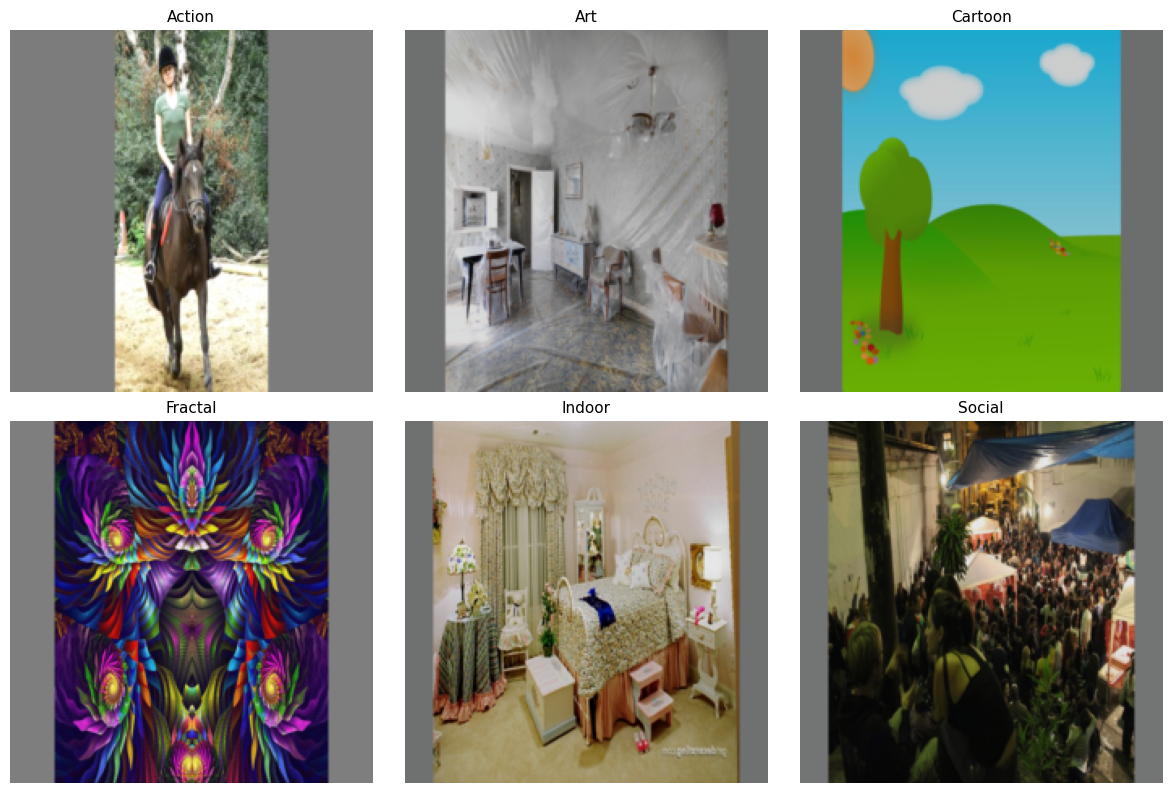

In [13]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, idx, cat in zip(axes.ravel(), selected_indices, chosen_categories):
    rgb = pretrained_inf["images"][idx].permute(1, 2, 0).numpy()
    rgb = rgb * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    rgb = np.clip(rgb, 0, 1)
    ax.imshow(rgb)
    ax.set_title(cat, fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()

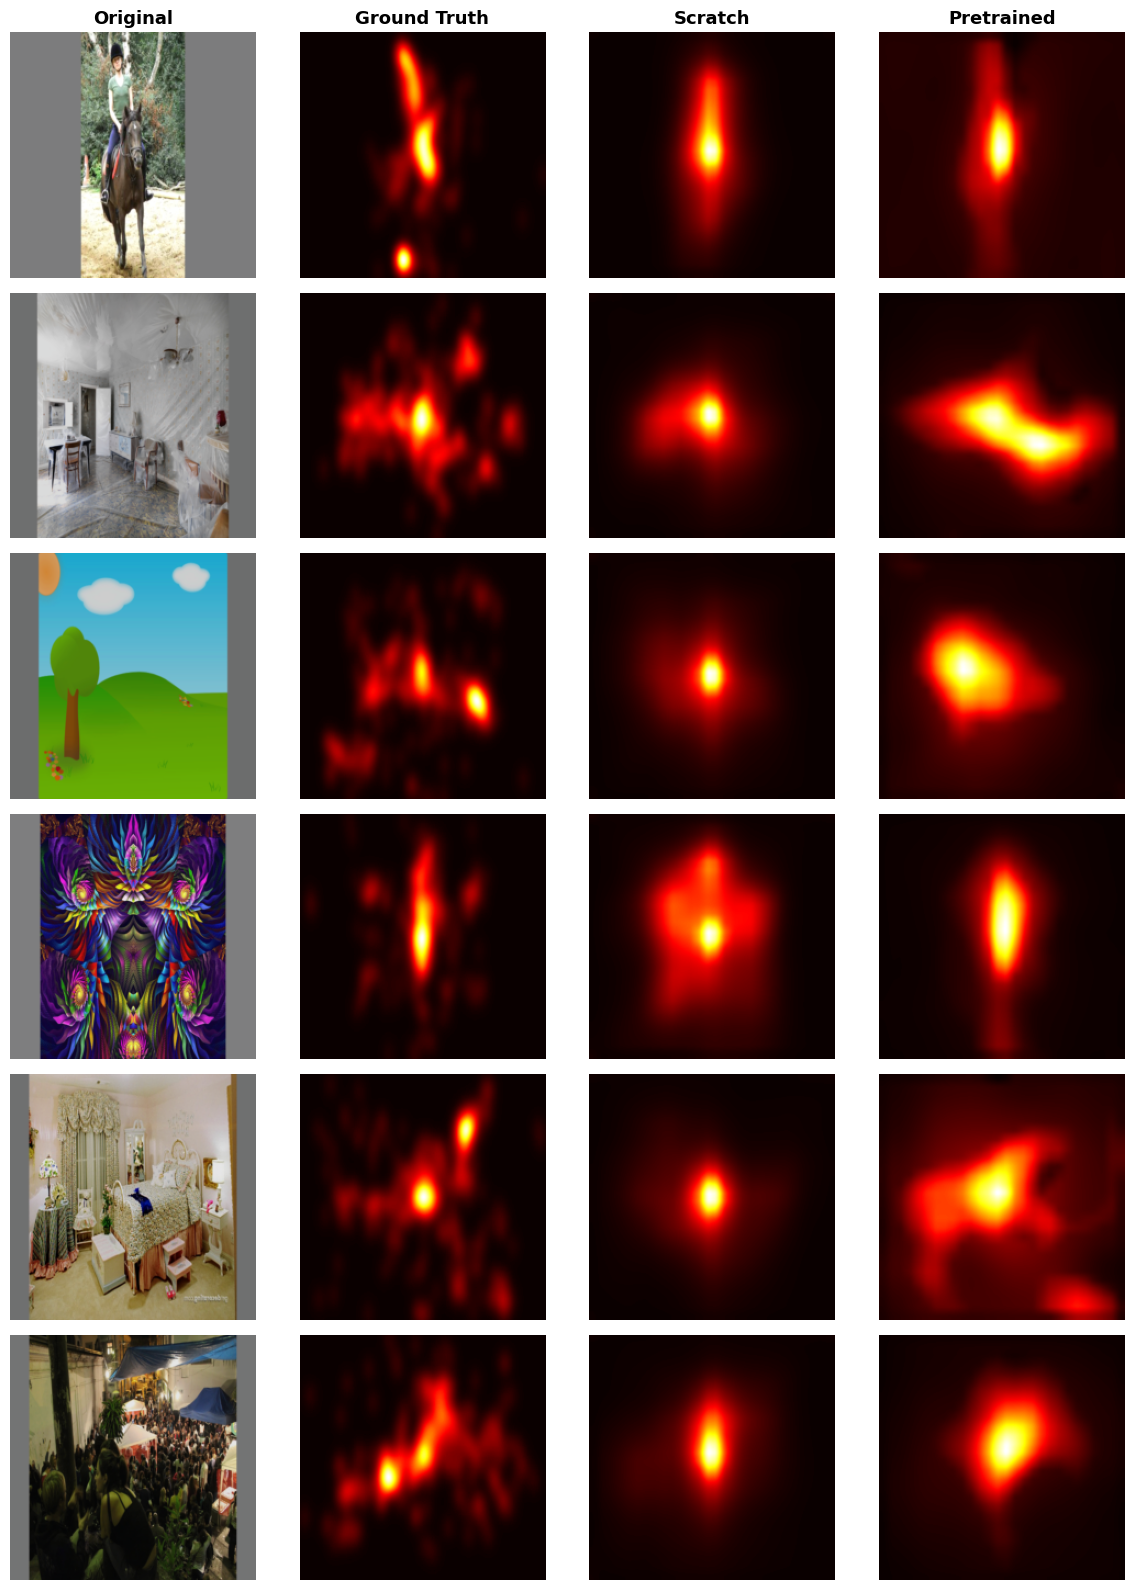

In [14]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(
    len(selected_indices),
    4,
    figsize=(12, 16)
)
column_titles = [
    "Original",
    "Ground Truth",
    "Scratch",
    "Pretrained"
]
for c, title in enumerate(column_titles):
    axes[0, c].set_title(title, fontsize=13, fontweight="bold")
for row, (idx, category) in enumerate(zip(selected_indices, chosen_categories)):
    rgb = pretrained_inf["images"][idx].permute(1, 2, 0).numpy()
    rgb = rgb * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    rgb = np.clip(rgb, 0, 1)
    gt = pretrained_inf["ground_truth"][idx, 0].numpy()
    scratch = scratch_inf["predictions"][idx, 0].numpy()
    pretrained = pretrained_inf["predictions"][idx, 0].numpy()
    images = [rgb, gt, scratch, pretrained]
    for col in range(4):
        if col == 0:
            axes[row, col].imshow(images[col])
        else:
            axes[row, col].imshow(images[col], cmap="hot")
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(
        category,
        rotation=90,
        fontsize=12,
        fontweight="bold"
    )
plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/CAT2000/analysis/Figure3_QualitativeComparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

pre_features = pretrained_inf["features"]
scr_features = scratch_inf["features"]
pre_features = pre_features.mean(dim=(2,3)).numpy() 
scr_features = scr_features.mean(dim=(2,3)).numpy() 

print(pre_features.shape)
print(scr_features.shape)

(240, 2048)
(240, 2048)


In [19]:
scaler = StandardScaler() 

combined = np.vstack([
    pre_features, 
    scr_features
])

combined = scaler.fit_transform(combined)
pca = PCA(n_components=2, random_state = 42)
embedding = pca.fit_transform(combined)
pre_embedding = embedding[:len(pre_features)]
scr_embedding = embedding[len(pre_features):]

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.7718202  0.05730073]


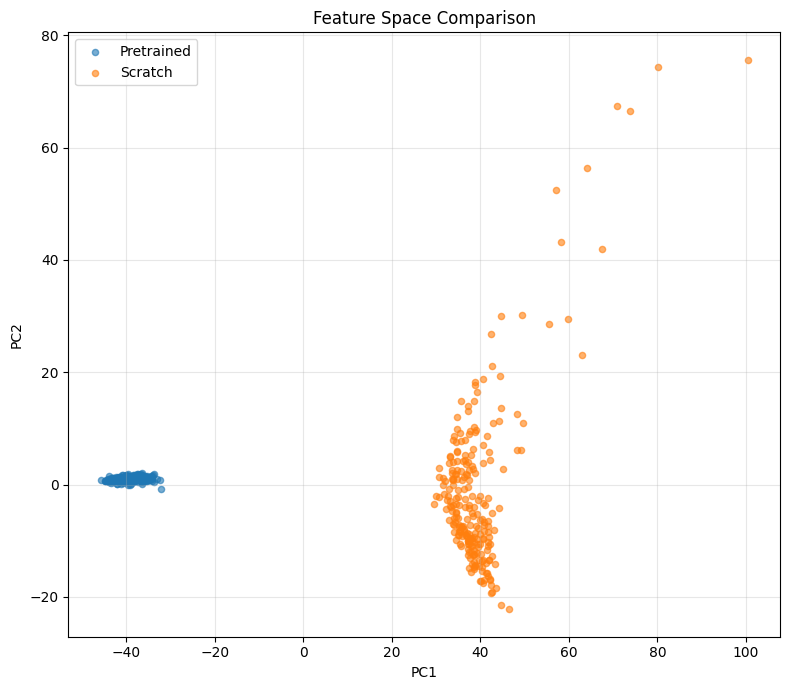

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 7))

plt.scatter(
    pre_embedding[:, 0],
    pre_embedding[:, 1],
    s=20,
    alpha=0.6,
    label="Pretrained"
)

plt.scatter(
    scr_embedding[:, 0],
    scr_embedding[:, 1],
    s=20,
    alpha=0.6,
    label="Scratch"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Feature Space Comparison")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/CAT2000/analysis/Figure4_PCA.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
import numpy as np

pre_history = np.load(
    "/content/drive/MyDrive/CAT2000/train_history.npy",
    allow_pickle=True
).item()

scratch_history = np.load(
    "/content/drive/MyDrive/CAT2000/scratch_train_history.npy",
    allow_pickle=True
).item()

print("Pretrained keys:")
print(pre_history.keys())

print("\nScratch keys:")
print(scratch_history.keys())

Pretrained keys:
dict_keys(['loss', 'cc', 'sim', 'smoothness', 'val_loss', 'val_cc', 'val_sim'])

Scratch keys:
dict_keys(['loss', 'cc', 'sim', 'smoothness', 'val_loss', 'val_cc', 'val_sim'])


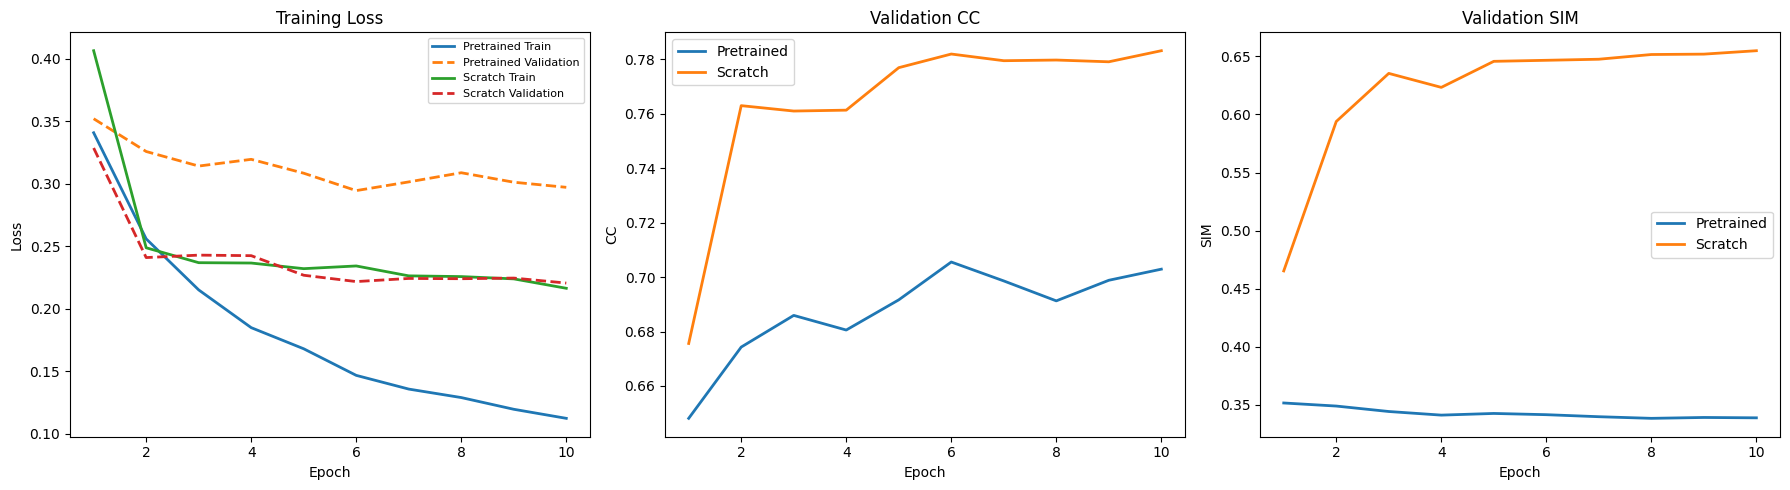

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(pre_history["loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(
    epochs,
    pre_history["loss"],
    label="Pretrained Train",
    linewidth=2
)

axes[0].plot(
    epochs,
    pre_history["val_loss"],
    "--",
    label="Pretrained Validation",
    linewidth=2
)

axes[0].plot(
    epochs,
    scratch_history["loss"],
    label="Scratch Train",
    linewidth=2
)

axes[0].plot(
    epochs,
    scratch_history["val_loss"],
    "--",
    label="Scratch Validation",
    linewidth=2
)

axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)

# -------------------------
# CC
# -------------------------
axes[1].plot(
    epochs,
    pre_history["val_cc"],
    label="Pretrained",
    linewidth=2
)

axes[1].plot(
    epochs,
    scratch_history["val_cc"],
    label="Scratch",
    linewidth=2
)

axes[1].set_title("Validation CC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("CC")
axes[1].legend()
axes[2].plot(
    epochs,
    pre_history["val_sim"],
    label="Pretrained",
    linewidth=2
)

axes[2].plot(
    epochs,
    scratch_history["val_sim"],
    label="Scratch",
    linewidth=2
)

axes[2].set_title("Validation SIM")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("SIM")
axes[2].legend()

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/CAT2000/analysis/Figure5_TrainingCurves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pre_features = pretrained_inf["features"].mean(dim=(2,3)).numpy()
scr_features = scratch_inf["features"].mean(dim=(2,3)).numpy()

# L2 normalize each feature vector
pre_features = normalize(pre_features, norm="l2")
scr_features = normalize(scr_features, norm="l2")

combined = np.vstack([pre_features, scr_features])

pca = PCA(n_components=2, random_state=42)

embedding = pca.fit_transform(combined)

pre_embedding = embedding[:len(pre_features)]
scr_embedding = embedding[len(pre_features):]

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.24423538 0.04059694]


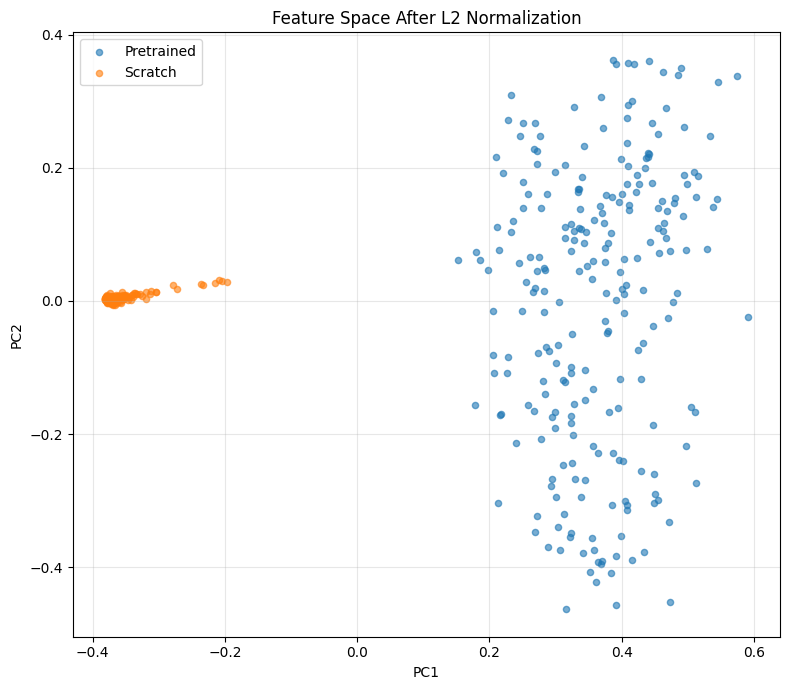

In [25]:
plt.figure(figsize=(8,7))

plt.scatter(
    pre_embedding[:,0],
    pre_embedding[:,1],
    s=20,
    alpha=0.6,
    label="Pretrained"
)

plt.scatter(
    scr_embedding[:,0],
    scr_embedding[:,1],
    s=20,
    alpha=0.6,
    label="Scratch"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Feature Space After L2 Normalization")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/CAT2000/analysis/Figure6_NormalizedPCA.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()